<a href="https://colab.research.google.com/github/ewelinakazimieruk02-lang/Python-Global-Sales-EDA-Logistics-Analytics/blob/main/Global%20Sales%20EDA%20%26%20Logistics%20Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Order Out of Chaos
# Python: Global Sales EDA & Logistics Analytics

In [ ]:
# 1. Przygotowanie środowiska do pracy
# a) Łączenie z bazą danych

from google.colab import drive
drive.mount('/content/drive')

# b) Import danych
import pandas as pd

events = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Module Task/events.csv')
products = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Module Task/products.csv')
countries = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Module Task/countries.csv')

events.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# 2. Czyszczenie danych
# a) Tabela Events

import pandas as pd

# Konwersja dat
events['Order Date'] = pd.to_datetime(events['Order Date'], dayfirst=False)
events['Ship Date'] = pd.to_datetime(events['Ship Date'], dayfirst=False)

# Usuwanie spacji
events['Sales Channel'] = events['Sales Channel'].str.strip()
events['Order Priority'] = events['Order Priority'].str.strip()
events['Country Code'] = events['Country Code'].str.strip()

# Standaryzacja wielkości liter
events['Sales Channel'] = events['Sales Channel'].str.title()
events['Order Priority'] = events['Order Priority'].str.upper()
events['Country Code'] = events['Country Code'].str.upper()

# Zamiana braków na NaN
events['Country Code'] = events['Country Code'].replace('#N/A', pd.NA)

# Sprawdzanie braków
events.isna().sum() #<--są 2 braki

# Usuwanie braków,żeby nie zaburzyc obliczen
events = events.dropna(subset=['Units Sold'])

# Country Code - jeśli pusty, zastąp Unknown (kolumna ta nie zaburza obliczeń)
events['Country Code'] = events['Country Code'].fillna('Unknown')

events['Sales Channel'] = events['Sales Channel'].astype('category')
events['Order Priority'] = events['Order Priority'].astype('category')
events['Country Code'] = events['Country Code'].astype('category')

# Czy są zduplikowane kolumny ?
events.duplicated().sum()

# Sprawdzanie potencjalnych błędów
# a) Czy wysyłka jest przed datą zamówienia?
events[events['Ship Date'] < events['Order Date']] # <-- Nie

# b) Czy są jakieś błędy w ilości sprzedanych produktów?
events[events['Units Sold'] < 0] # <-- Nie

# c) Cena są przypadki, gdzie cena jest mniejsza niż koszt ?
events[events['Unit Price'] < events['Unit Cost']] # <-- Nie

#print(events)

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
# 2. Czyszczenie danych
# b) Tabela Products

products.info()
products.isna().sum()
products.duplicated().sum()

products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# 2. Czyszczenie danych
# c) Tabela Countries

countries.info()
countries.isna().sum() # <-- braki: alpha-2: 1, region: 1, sub-region	1
countries.duplicated().sum()

# Zastąpienie brakuących wartości przez "Unknown"
countries['sub-region'] = countries['sub-region'].fillna('Unknown')
countries['region'] = countries['region'].fillna('Unknown')
countries['alpha-2'] = countries['alpha-2'].fillna('Unknown')

countries.isna().sum()
#countries.head()

print(countries)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
                  name alpha-2 alpha-3   region          sub-region
0          Afghanistan      AF     AFG     Asia       Southern Asia
1        Åland Islands      AX     ALA   Europe     Northern Europe
2              Albania      AL     ALB   Europe     Southern Europe
3              Algeria      DZ     DZA   Africa     Northern Africa
4       American Samoa      AS     ASM  Oceania           Polynesia
..                 ...     ...     ...      ...                 ...
244  Wallis and Futuna      WF     WLF  Oceania           Polynesia
245     Western Sahara      EH  

In [ ]:
# 3. Łączenie tabel
# a) Events + Products

df = events.merge(
    products,
    how='left',
    left_on='Product ID',
    right_on='id'
)

# b) Df + Countries

df = pd.merge(
    df,
    countries,
    left_on='Country Code',
    right_on='alpha-3',
    how='left'
)

print(df)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# 4. Ujednolicenie nazw kolumn
df = df.rename(
    columns={
        'name': 'Country',
        'region': 'Region',
        'sub-region': 'Sub-Region'
    }
)


print(df)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# 5. Usuwanie zbędnych kolumn
df = df.drop(columns=['id', 'alpha-2', 'alpha-3'])

print(df)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# 6. Obliczanie kluczowyh wskaźników wydajności firmy - KPI
# a) Dodawanie nowych kolumn z obliczeniami

df['Revenue'] = df['Units Sold'] * df['Unit Price']
df['Cost'] = df['Units Sold'] * df['Unit Cost']
df['Profit'] = df['Revenue'] - df['Cost']

print(df)


       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# 6. Obliczanie kluczowyh wskaźników wydajności firmy - KPI
# b) Główne obliczenia

orders_count = df['Order ID'].count() # 0bliczanie liczby zamówień
print(f"Liczba zamówień:{orders_count} ")

total_countries = df['Country'].nunique() # Ile krajów obsługuje firma
print(f"Liczba państw:{total_countries}")

total_products = df['Product ID'].nunique() # Ile produktów sprzedaje firma
print(f"Liczba produktów:{total_products}")

total_revenues = df['Revenue'].sum() # Liczenie całkowitego przychodu
print(f"Całkowity przychód:{total_revenues}")

total_costs = df['Cost'].sum() # Liczenie całkowitego kosztu
print(f"Całkowity koszt:{total_costs}")

total_profit = df['Profit'].sum() # Liczenie całkowitego zysku
print(f"Całkowity zysk:{total_profit}")



Liczba zamówień:1328 
Liczba państw:45
Liczba produktów:12
Całkowity przychód:1702129408.21
Całkowity koszt:1200694949.21
Całkowity zysk:501434459.0


item_type
Baby Food          1.436476e+08
Beverages          2.909316e+07
Cereal             9.579140e+07
Clothes            6.462655e+07
Cosmetics          2.331548e+08
Fruits             5.520300e+06
Household          2.942052e+08
Meat               2.237620e+08
Office Supplies    4.022140e+08
Personal Care      4.557902e+07
Snacks             7.478861e+07
Vegetables         8.974673e+07
Name: Revenue, dtype: float64


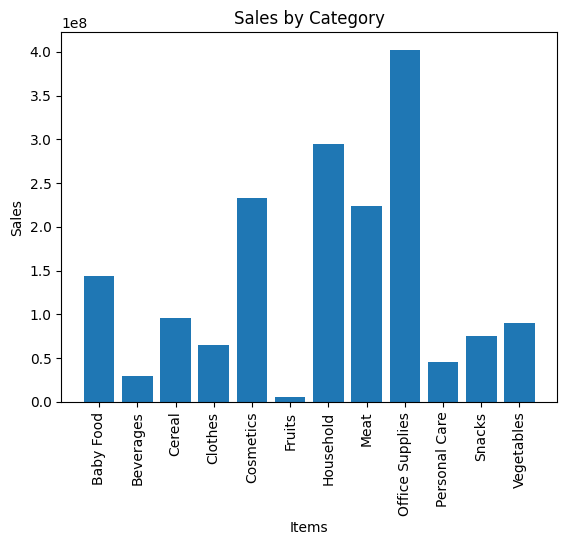

In [ ]:
# 7. Analiza sprzedaży według produktów
# a) Grupowanie po produktach

sales_by_category = df.groupby('item_type')['Revenue'].sum()
print(sales_by_category)

# b) Wykres przychody wg produktów
import matplotlib.pyplot as plt

plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Sales by Category")
plt.xlabel("Items")
plt.ylabel("Sales")

plt.xticks(rotation=90)
plt.show()


Sprzedaż jest silnie skoncentrowana w kilku kategoriach. Największe przychody generują Office Supplies, Household i Cosmetics, co wskazuje na ich kluczową rolę w biznesie. Najsłabsze wyniki mają Fruits, Baverages i Personal Care, co sugeruje niski popyt lub mniejszą skalę działania.

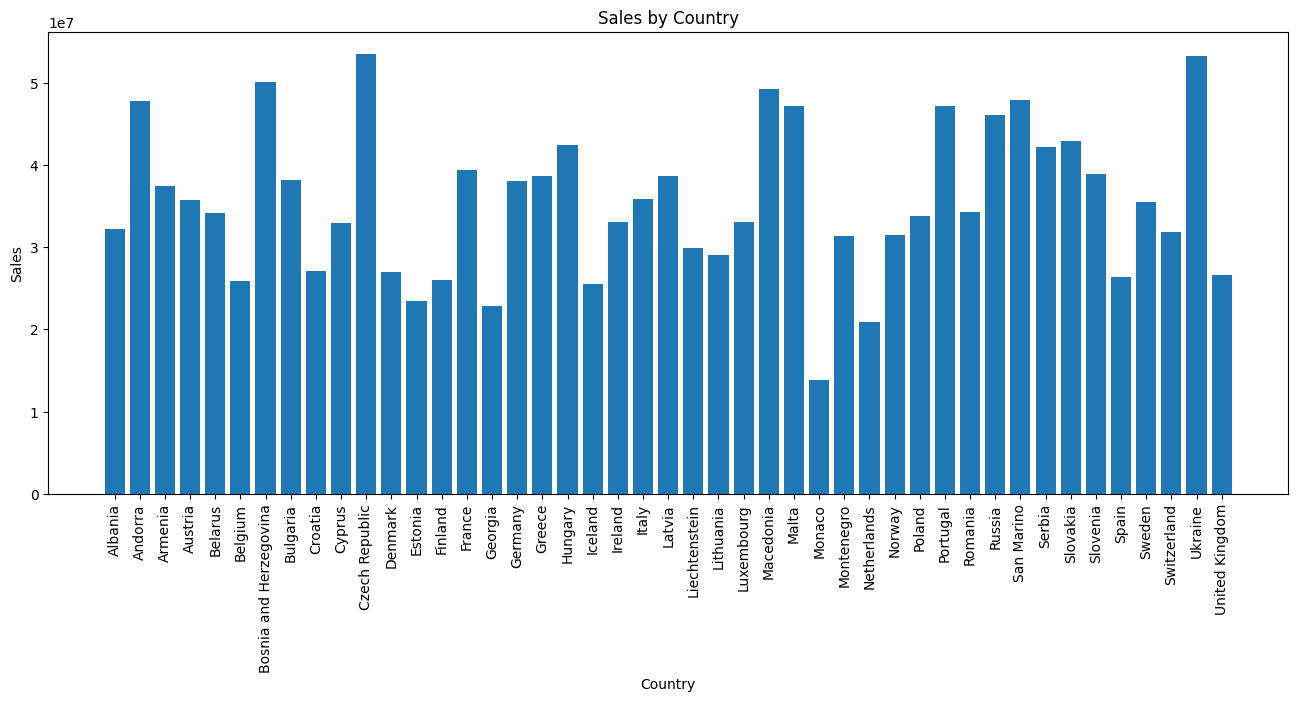

In [ ]:
# 8. Analiza sprzedaży według kraju
# a) Grupowanie po krajach

sales_by_country = df.groupby('Country')['Revenue'].sum()
#print(sales_by_country)

# b) Wykres przchody wg kraju
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.bar(sales_by_country.index, sales_by_country.values)
plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()


Sprzedaż znacząco różni się między krajami. Kluczowe rynki to: Czechy, Ukraina oraz Bośnia i Hercegowina. Najniższą sprzedaż odnotowano w Monako, Estonii i Gruzji, co wskazuje na marginalny udział tych krajów w całkowitych przychodach.

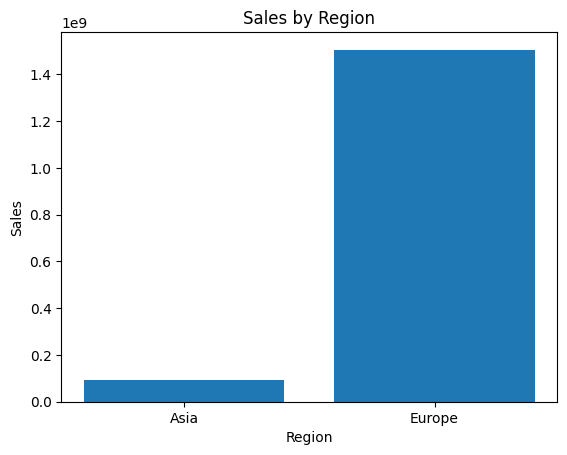

In [ ]:
# 9. Analiza sprzedaży według regionu
# a) Grupowanie po regionach
sales_by_region = df.groupby('Region')['Revenue'].sum()

# b) Wykres sprzedaż wg regionu
import matplotlib.pyplot as plt

plt.bar(sales_by_region.index, sales_by_region.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()


Europa zdecydowanie dominuje, odpowiadając za większość sprzedaży firmy. Azja ma znacznie niższy udział, co może oznaczać niewykorzystany potencjał lub ograniczoną obecność firmy na tym rynku.

/tmp/ipykernel_575/1350947447.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_channel = df.groupby('Sales Channel')['Revenue'].sum()


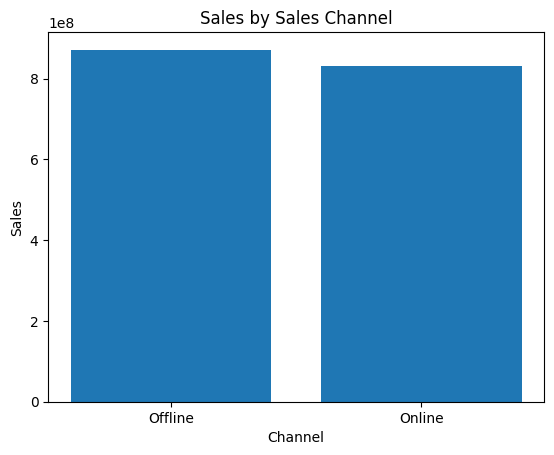

In [ ]:
# 10. Analiza sprzedaży według źródła
# a) Grupowanie po Channel
sales_by_channel = df.groupby('Sales Channel')['Revenue'].sum()

# b) Wykres sprzedaż wg źródło
import matplotlib.pyplot as plt

plt.bar(sales_by_channel.index, sales_by_channel.values)
plt.title("Sales by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Sales")
plt.show()



Sprzedaż offline jest nieco wyższa niż online, ale oba kanały mają zbliżony udział. Oznacza to, że firma powinna utrzymywać oba kanały, a kanał online może być dobrym kierunkiem dalszego rozwoju.

item_type
Baby Food          8.970659e+07
Beverages          1.949150e+07
Cereal             5.453637e+07
Clothes            2.119524e+07
Cosmetics          1.404315e+08
Fruits             4.094370e+06
Household          2.212427e+08
Meat               1.934243e+08
Office Supplies    3.242368e+08
Personal Care      3.160361e+07
Snacks             4.776119e+07
Vegetables         5.297073e+07
Name: Cost, dtype: float64


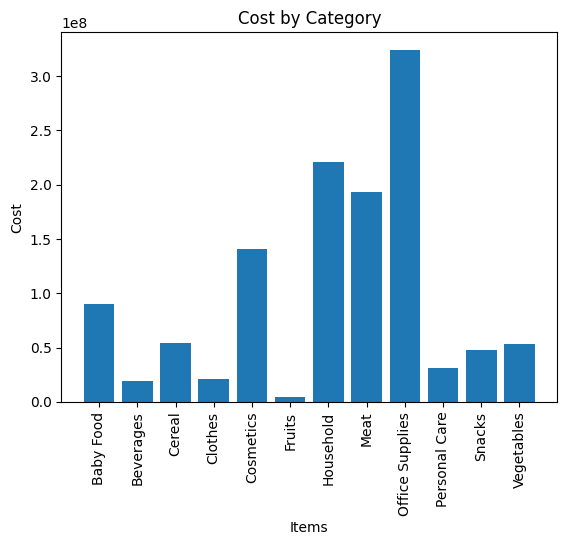

In [ ]:
# 11. Analiza kosztu według kategorii
# a) Grupowanie po kategorii
cost_by_category = df.groupby('item_type')['Cost'].sum()

print(cost_by_category)

# b) Wykres koszt vs produkt
import matplotlib.pyplot as plt
plt.bar(cost_by_category.index, cost_by_category.values)
plt.title("Cost by Category")
plt.xlabel("Items")
plt.ylabel("Cost")
plt.xticks(rotation=90)
plt.show()


Najwyższe koszty generują Office Supplies, Household i Meat - to najbardziej kosztowne obszary działalności. Najniższe koszty dotyczą Fruits, Beverages i Clothes, co wskazuje na mniejszą skalę lub niższe koszty jednostkowe w tych kategoriach.

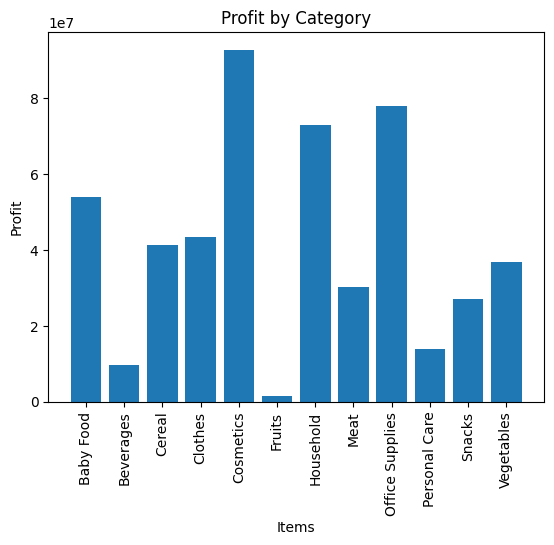

In [ ]:
# 12. Analiza zysku wedłu kategorii
# a) Grupowanie po kategorii
profit_by_category = df.groupby('item_type')['Profit'].sum()

# b) Wykres zysk vs produkt
import matplotlib.pyplot as plt
plt.bar(profit_by_category.index, profit_by_category.values)
plt.title("Profit by Category")
plt.xlabel("Items")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.show()


Najwyższy zysk generują Cosmetics, Office Supplies oraz Household - to najbardziej dochodowe obszary działalności. Najniższy zysk natomiast, generują Fruits, Baverages oraz Personal care.

item_type
Baby Food          562706.0
Beverages          613133.0
Cereal             465685.0
Clothes            591385.0
Cosmetics          533291.0
Fruits             591672.0
Household          440249.0
Meat               530380.0
Office Supplies    617641.0
Personal Care      557678.0
Snacks             490160.0
Vegetables         582544.0
Name: Units Sold, dtype: float64


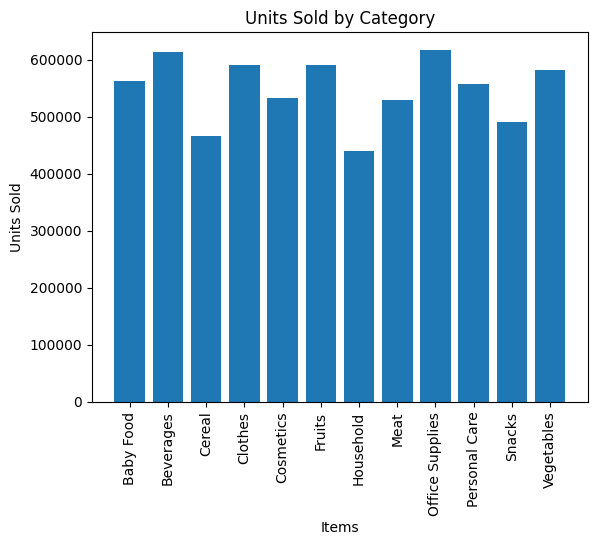

In [ ]:
# 13. Analiza popularnośći produktów
# a) Grupowanie po kategorii
units_by_category = df.groupby('item_type')['Units Sold'].sum()

print(units_by_category)
# Wykres produkt vs jego sprzedaż
import matplotlib.pyplot as plt
plt.bar(units_by_category.index, units_by_category.values)
plt.title("Units Sold by Category")
plt.xlabel("Items")
plt.ylabel("Units Sold")
plt.xticks(rotation=90)
plt.show()


Najpopularniejsze produkty to Office Supplies, Beverages i Fruits - generują najwyższy wolumen sprzedaży. Najmniej popularne są Household, Cereal i Snacks, co wskazuje na niższy popyt lub mniejszą rotację tych kategorii.

In [ ]:
# 14. Analiza czasu wysyłki
# Dodanie i obliczenie kolumny z czasem wysyłki
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date'])
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
# bez tego, w późniejszym kroku wykres czas wysyłki vs zysk nie rozsypuje

df[['Order Date', 'Ship Date', 'Shipping_Days']].head()



,Order Date,Ship Date,Shipping_Days
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2014-07-18,2014-08-11,24
3,2017-05-13,2017-06-13,31
4,2012-08-11,2012-09-18,38


item_type
Personal Care      20.763158
Clothes            23.104762
Vegetables         23.491228
Household          23.938144
Beverages          24.123967
Fruits             24.419643
Snacks             25.543689
Meat               25.909091
Cosmetics          25.912281
Baby Food          26.339286
Office Supplies    26.707317
Cereal             27.184466
Name: Shipping_Days, dtype: float64


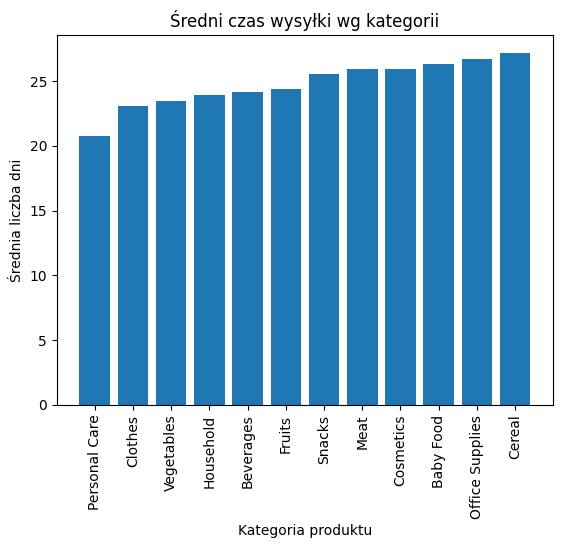

In [ ]:
# 14. Analiza czasu wysyłki
# a) Średni czas wysyłki wg kategorii
shipping_by_category = df.groupby('item_type')['Shipping_Days'].mean()

# Sortowanie (domyślnie, rosnąco)
shipping_by_category = shipping_by_category.sort_values()

print(shipping_by_category)

# Wykres czas wysyłki vs kategoria
import matplotlib.pyplot as plt
plt.bar(shipping_by_category.index, shipping_by_category.values)
plt.title("Średni czas wysyłki wg kategorii")
plt.xlabel("Kategoria produktu")
plt.ylabel("Średnia liczba dni")
plt.xticks(rotation=90)
plt.show()



Najkrótszy czas wysyłki dotyczy Personal Care, Clothes i Vegetables, co sugeruje sprawniejszą logistykę w tych kategoriach. Najdłużej wysyłane są Cereal, Office Supplies i Baby Food, co może wskazywać na bardziej złożony proces kompletacji lub większe obciążenie magazynów.

Country
Croatia                   18.352941
United Kingdom            18.391304
Denmark                   19.692308
Estonia                   20.521739
Serbia                    20.586207
Latvia                    20.888889
Malta                     21.562500
San Marino                21.700000
Liechtenstein             22.958333
Greece                    23.000000
Macedonia                 23.218750
Cyprus                    23.233333
Germany                   23.423077
Ireland                   23.533333
Iceland                   23.565217
Slovenia                  23.740741
Switzerland               24.000000
Norway                    24.100000
Portugal                  24.120000
Romania                   24.941176
Sweden                    25.137931
Italy                     25.200000
Czech Republic            25.225806
Belarus                   25.250000
Ukraine                   25.757576
Bosnia and Herzegovina    26.060606
Armenia                   26.172414
Albania             

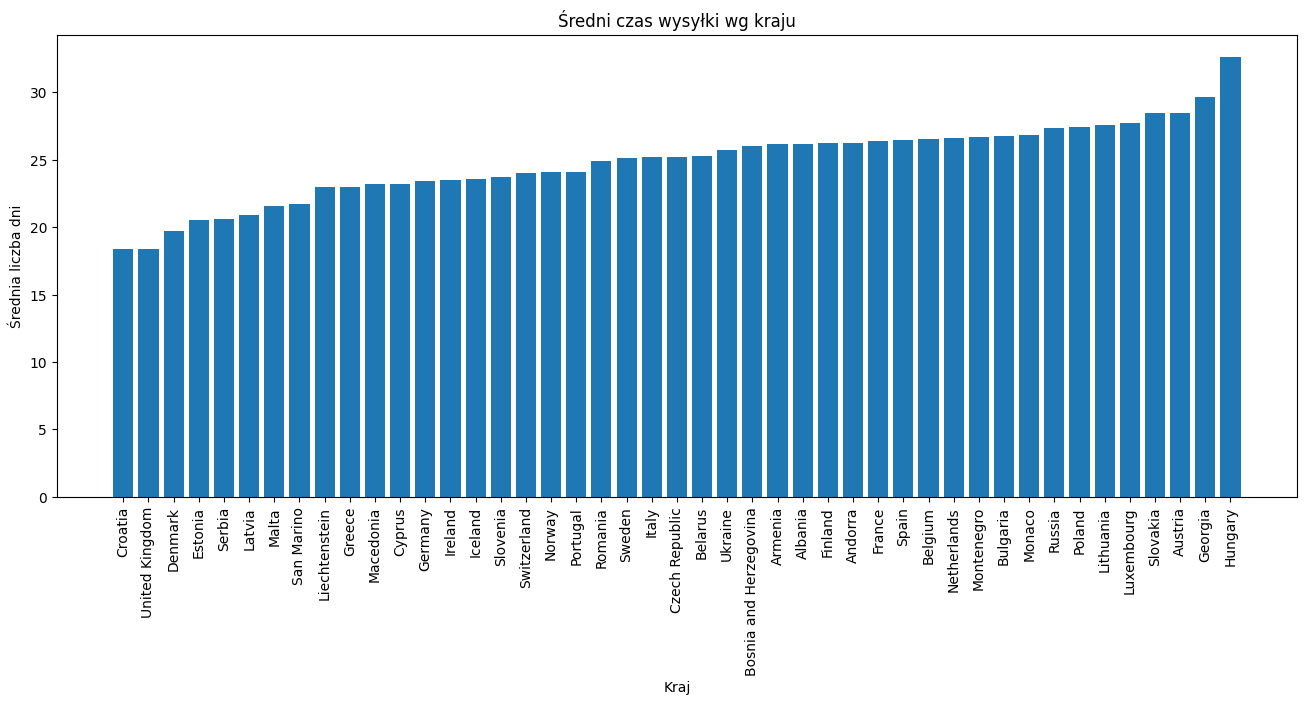

In [ ]:
# 14. Analiza czasu wysyłki
# b) Średni czas wysyłki wg kraju
shipping_by_country = df.groupby('Country')['Shipping_Days'].mean()

# Sortowanie (domyślnie, rosnąco)
shipping_by_country = shipping_by_country.sort_values()

print(shipping_by_country)

# Wykres czas wysyłki vs kraj
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
plt.bar(shipping_by_country.index, shipping_by_country.values)
plt.title("Średni czas wysyłki wg kraju")
plt.xlabel("Kraj")
plt.ylabel("Średnia liczba dni")
plt.xticks(rotation=90)
plt.show()


Najszybszą wysyłkę odnotowano w Chorwacji, Wielkiej Brytanii i Danii, natomiast najdłuższy czas realizacji występuje na Węgrzech, w Gruzji i Austrii. Różnice wskazują na zróżnicowaną efektywność logistyczną między krajami.


Region
Europe    24.790378
Asia      26.085366
Name: Shipping_Days, dtype: float64


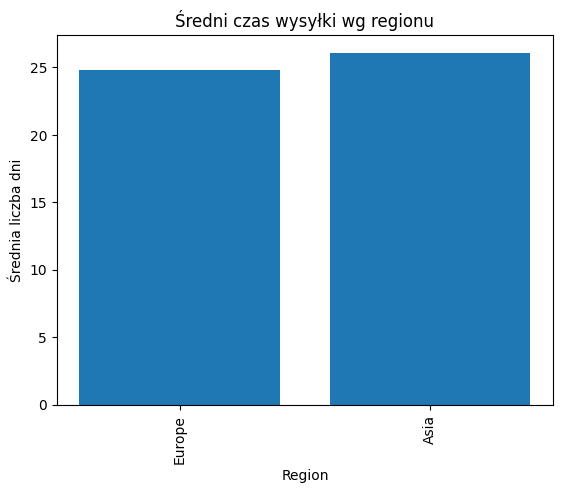

In [ ]:
# 14. Analiza czasu wysyłki
# c) Średni czas wysyłki wg regionu
shipping_by_region = df.groupby('Region')['Shipping_Days'].mean()

# Sortowanie (domyślnie, rosnąco)
shipping_by_region = shipping_by_region.sort_values()

print(shipping_by_region)

# Wykres czas wysyłki vs region
import matplotlib.pyplot as plt
plt.bar(shipping_by_region.index, shipping_by_region.values)
plt.title("Średni czas wysyłki wg regionu")
plt.xlabel("Region")
plt.ylabel("Średnia liczba dni")
plt.xticks(rotation=90)
plt.show()

Wysyłka w Europie jest szybsza niż w Azji. Oznacza to, że proces logistyczny w Europie działa sprawniej, podczas gdy w Azji realizacja zamówień trwa nieco dłużej



Shipping_Days
10    212348.587500
20    262167.901154
48    277767.119643
15    284953.289655
3     285222.778788
34    287320.360000
27    293306.714783
4     300644.403548
18    301355.463529
50    304252.151905
14    307127.478333
1     309541.679091
13    314848.072500
42    320388.368500
32    321988.168611
23    332977.686429
2     339626.031154
8     344957.536250
22    348334.737222
0     348379.706000
45    351263.147083
24    363664.241379
6     366050.053462
29    367156.532917
25    368206.628750
35    370739.592174
12    372993.060968
37    377464.549259
26    381526.989200
28    384516.750625
44    393351.696875
21    393514.420294
43    393550.263333
39    394143.859231
7     400718.312812
11    409519.580000
5     417644.889259
9     424283.931786
16    435537.343636
41    436604.784762
17    438769.952143
19    447036.297500
49    449198.790400
46    449214.668462
31    465211.364242
38    479009.872692
33    488020.626818
30    495657.887222
36    497836.397407
40    

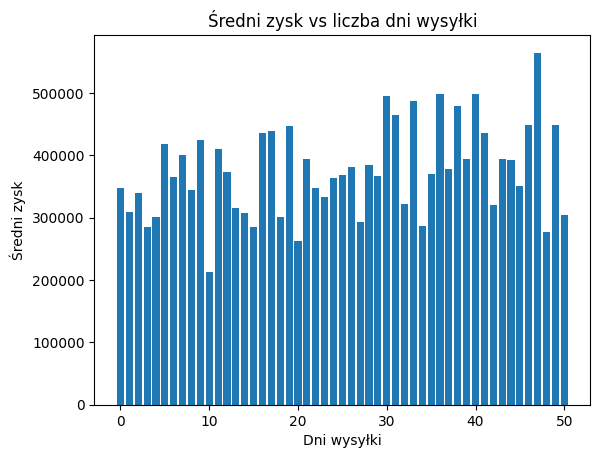

In [ ]:
# 14. Analiza czasu wysyłki
# d) Sprawdzeie czy czas wysyłki wpływa na zysk.
profit_by_shipping = df.groupby('Shipping_Days')['Profit'].mean()

# Sortowanie (domyślnie, rosnąco)
profit_by_shipping = profit_by_shipping.sort_values()

print(profit_by_shipping)

# Wykres czas wysyłki vs zysk
plt.bar(profit_by_shipping.index, profit_by_shipping.values)
plt.title("Średni zysk vs liczba dni wysyłki")
plt.xlabel("Dni wysyłki")
plt.ylabel("Średni zysk")
plt.show()


Średni zysk rośnie wraz z czasem wysyłki - szybkie wysyłki generują najniższy profit, natomiast najdłuższe (40–50 dni) osiągają najwyższe wartości. Oznacza to, że produkty wymagające dłuższej realizacji są jednocześnie bardziej dochodowe.

YearMonth
2010-1     21115354.48
2010-10    23899826.50
2010-11     6043009.16
2010-12    30652728.06
2010-2     19853023.20
              ...     
2017-3     24088987.50
2017-4     14397482.38
2017-5     20279233.36
2017-6     16855010.05
2017-7     23536290.16
Name: Revenue, Length: 91, dtype: float64


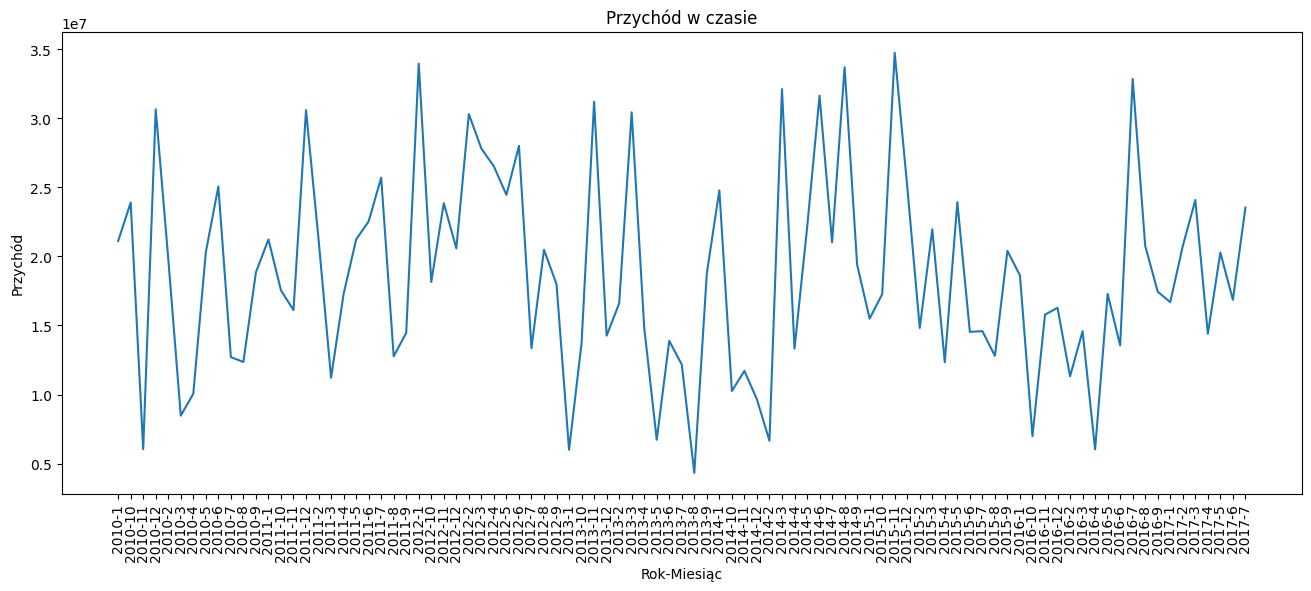

In [ ]:
# 15. Dynamika sprzedaży w czasie
# Rok-miesiąc do analizy trendu
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Dzień tygodnia do analizy
df['DayOfWeek'] = df['Order Date'].dt.day_name()

# Przekszatałcenie danych na Year-Month, żeby zadziałał wykres
df['YearMonth'] = df['Year'].astype(str) + '-' + df['Month'].astype(str)

# Grupowanie po roku i miesiacu
sales_over_time = df.groupby('YearMonth')['Revenue'].sum()

print(sales_over_time)

# Wizaulizacja dynamiki sprzedaży w czasie
plt.figure(figsize=(16,6))
plt.plot(sales_over_time.index, sales_over_time.values)
plt.title("Przychód w czasie")
plt.xlabel("Rok-Miesiąc")
plt.ylabel("Przychód")
plt.xticks(rotation=90)
plt.show()



Przychody w czasie są mocno sezonowe - najwyższe wartości pojawiają się pod koniec roku, a najniższe w pojedynczych słabszych miesiącach. Ogólny poziom sprzedaży pozostaje stabilny, bez wyraźnego trendu wzrostowego lub spadkowego.

DayOfWeek
Friday       2.638070e+08
Monday       2.754685e+08
Saturday     2.336411e+08
Sunday       2.395510e+08
Thursday     2.149222e+08
Tuesday      2.135239e+08
Wednesday    2.612157e+08
Name: Revenue, dtype: float64


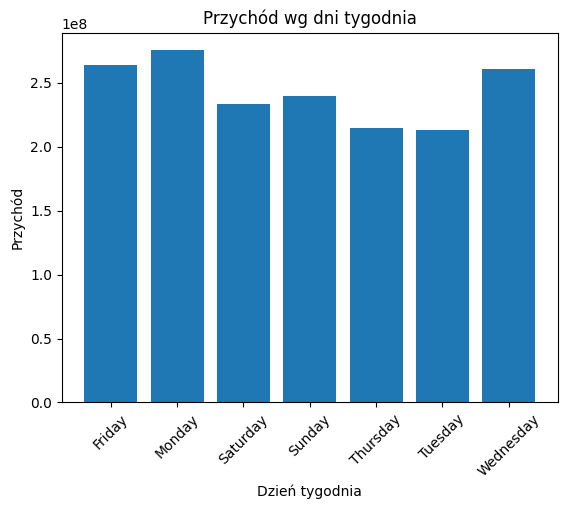

In [ ]:
# 16. Sprzedaż wg dni tygodnia
sales_by_day = df.groupby('DayOfWeek')['Revenue'].sum()

print(sales_by_day)

# Wykres przychód vs dzień tygodnia
plt.bar(sales_by_day.index, sales_by_day.values)
plt.title("Przychód wg dni tygodnia")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()



Najwyższy przychód generowany jest na początku tygodnia - w poniedziałek, środę, ale również w piątek. Najsłabsze wyniki notują wtorek, czwartek i sobota, co wskazuje na wyraźne różnice w aktywności klientów między dniami tygodnia.

DayOfWeek
Friday       12884430.9
Monday        8572341.8
Saturday     19802533.3
Sunday       18619141.2
Thursday     11986961.8
Tuesday      11950758.6
Wednesday    11975236.9
Name: Revenue, dtype: float64


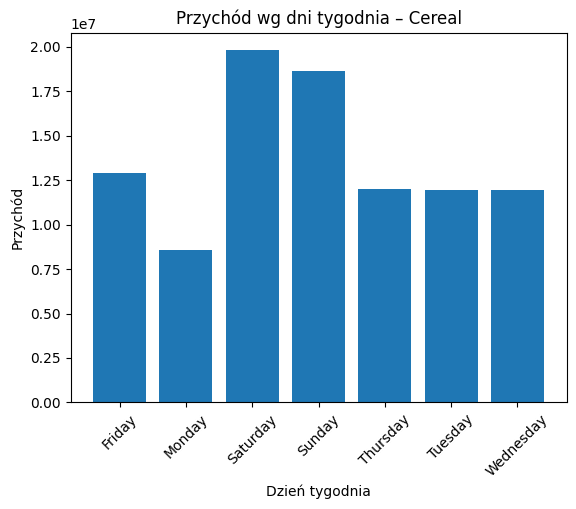

In [ ]:
# 17. Sprawdzenie czy istnieją sezonowe produkty

# Lista dostępnych produktów
df['item_type'].unique()

# Filtrowanie po kategorii Cereal
temp = df[df['item_type'] == 'Cereal']

# Grupowanie
sales_cereal_by_day = temp.groupby('DayOfWeek')['Revenue'].sum()

print(sales_cereal_by_day)

# Wykres wybranego produktu: Cereal vs przychód
plt.bar(sales_cereal_by_day.index, sales_cereal_by_day.values)
plt.title("Przychód wg dni tygodnia – Cereal")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()


Cereal, czy jest sezonowość? - Tak.
Najwyższa sprzedaż: Saturday, Sunday  
Najniższa sprzedaż: Monday

Różnice są duże - wyraźny wzrost w weekend, spadek na początku tygodnia.

DayOfWeek
Friday        6696022.72
Monday        7442951.52
Saturday     11023510.72
Sunday       11471449.44
Thursday      9657620.00
Tuesday      13577165.76
Wednesday     4757832.64
Name: Revenue, dtype: float64


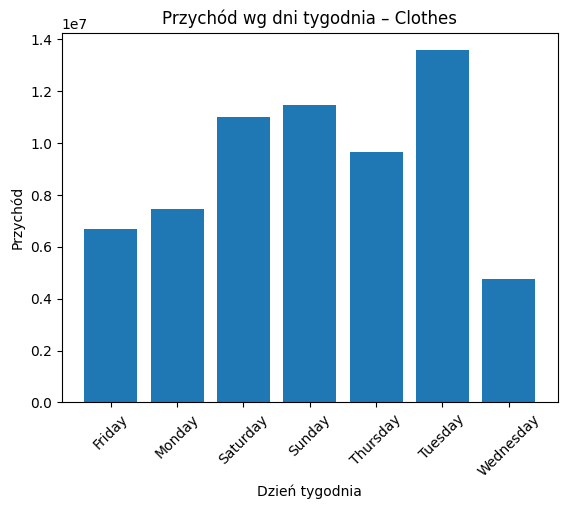

In [ ]:
# 17. Sprawdzenie czy istnieją sezonowe produkty

# Filtrowanie po kategorii Clothes
temp2 = df[df['item_type'] == 'Clothes']

# Grupowanie
sales_clothes_by_day = temp2.groupby('DayOfWeek')['Revenue'].sum()

print(sales_clothes_by_day)

# Wykres wybranego produktu: Clothes vs przychód
plt.bar(sales_clothes_by_day.index, sales_clothes_by_day.values)
plt.title("Przychód wg dni tygodnia – Clothes")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()





Clothes, czy jest sezonowość? - Tak.
Najwyższa sprzedaż: Tuesday, Sunday, Saturday  
Najniższa sprzedaż: Wednesday

Różnice są ogromne (np. wtorek ponad 13 mln vs środa 4,7 mln) - silna sezonowość tygodniowa.

DayOfWeek
Friday       61875167.2
Monday       24434233.6
Saturday     28455599.2
Sunday       21913775.6
Thursday     30887742.8
Tuesday      35592014.8
Wednesday    29996292.0
Name: Revenue, dtype: float64


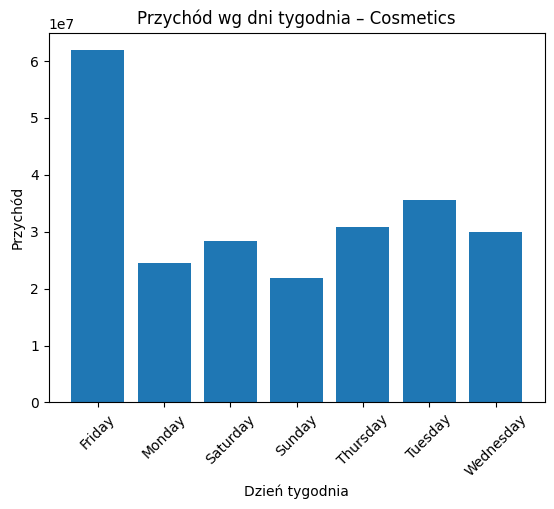

In [ ]:
# 17. Sprawdzenie czy istnieją sezonowe produkty

# Filtrowanie po kategorii Cosmetics
temp3 = df[df['item_type'] == 'Cosmetics']

# Grupowanie
sales_cosmetics_by_day = temp3.groupby('DayOfWeek')['Revenue'].sum()

print(sales_cosmetics_by_day)

# Wykres wybranego produktu: Cosmetics vs przychód
plt.bar(sales_cosmetics_by_day.index, sales_cosmetics_by_day.values)
plt.title("Przychód wg dni tygodnia – Cosmetics")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()


Cosmetics, czy jest sezonowość? -Tak.
Najwyższa sprzedaż: Friday, Tuesday  
Najniższa sprzedaż: Monday, Sunday

Różnice są duże, ale nie tak ekstremalne jak w Clothes - sezonowość obecna, ale umiarkowana.

Czy na podstawie tych przykładów można stwierdzić, że istnieją produkty sezonowe?
Tak.  
Wszystkie trzy kategorie (Cereal, Clothes, Cosmetics) pokazują wyraźne różnice sprzedaży między dniami tygodnia, a w przypadku Clothes - bardzo silne. Nie mniej jednak sezonowość, dla każdego ze sprawdzanych prduktów, oznacza zupełnie inne dni.

ANALIZA SPRZEDAŻY – FIRMA XYZ

1. Kluczowe wskaźniki
Liczba zamówień: 1328
Liczba krajów: 45
Liczba produktów: 12
Całkowity przychód: 1 702 129 408.21 PLN
Całkowity koszt: 1 200 694 949.21 PLN
Całkowity zysk: 501 434 459.00 PLN

2. Sprzedaż według kategorii
Największy przychód generują:
Office Supplies
Household
Cosmetics
To kluczowe filary biznesu - kategorie o największym znaczeniu strategicznym.
Najniższy przychód generują:
Fruits
Beverages
Personal Care
To obszary o niskim popycie lub małej skali działania.


Kategorie o najwyższych przychodach (Office Supplies, Household) mają również wysokie koszty, ale  jednocześnie generują wysoki zysk, co oznacza, że są efektywne marżowo.

3. Zysk według kategorii
Najbardziej dochodowe kategorie:
Cosmetics
Office Supplies
Household
To obszary, które powinny być priorytetem inwestycyjnym.
Najmniej dochodowe:
Fruits
Beverages
Personal Care
Warto rozważyć optymalizację cen, kosztów lub ograniczenie oferty.

4. Popularność produktów (wolumen sprzedaży)
Najpopularniejsze:
Office Supplies
Beverages
Fruits
Duży wolumen = wysoka rotacja = stabilny popyt.
Najmniej popularne:
Household
Cereal
Snacks
Niska rotacja - możliwe przepełnienie magazynu lub słaba atrakcyjność.

5. Sprzedaż według lokalizacji
Najsilniejsze rynki:
Czech Republic
Ukraine
Bosnia and Herzegovina
To kraje generujące największy przychód — kluczowe dla strategii firmy.
Najsłabsze rynki:
Monaco
Estonia
Georgia
Marginalny udział - potencjalnie nieopłacalne rynki.
Regiony:
Europa dominuje - najwyższa sprzedaż i szybsza logistyka.
Azja ma niższy udział - potencjał do rozwoju, ale wymaga inwestycji.

6. Kanały sprzedaży
Sprzedaż offline jest nieco wyższa niż online, ale różnica jest niewielka.
Oba kanały są istotne - online ma potencjał wzrostu.

7. Koszty według kategorii
Najwyższe koszty:
Office Supplies
Household
Meat
To najbardziej kosztowne obszary działalności, ale w przypadku Office Supplies oraz Household, jest to powiązane z dużym zyskiem. Oznacza to, że inwestycja w te produkty się opłaca.
Najniższe koszty:
Fruits
Beverages
Clothes
Niska skala lub niskie koszty jednostkowe.W przypadku Fruits i Beverages, kategorie te generują również najniższy zysk.

8. Czas wysyłki
Najszybsza wysyłka (kategorie):
Personal Care
Clothes
Vegetables
Najwolniejsza wysyłka (kategorie):
Cereal
Office Supplies
Baby Food
Najszybsza wysyłka do krajów:
Croatia
United Kingdom
Denmark
Najwolniejsza wysyłka do krajów:
Hungary
Georgia
Austria
Regiony:
Europa wysyła szybciej niż Azja.
Zysk a czas wysyłki:
Zysk rośnie wraz z czasem wysyłki.
 Produkty wysyłane długo są droższe i bardziej marżowe.

9. Dynamika sprzedaży w czasie
Najwyższe przychody: końcówka roku (grudzień).
Najniższe: pojedyncze słabsze miesiące (np. listopad 2010).
Trend: stabilny, z wyraźną sezonowością miesięczną.

10. Sprzedaż wg dni tygodnia
Najwyższa sprzedaż:
Monday
Wednesday
Friday
Najsłabsza sprzedaż:
Tuesday
Thursday
Saturday

11. Sezonowość produktów
Sezonowość została sprawdzona na podstawie 3 wybranych produktów, takich jak:


Cereal
Sezonowość: tak
Najwyższa sprzedaż: Saturday, Sunday
Najniższa: Monday
Clothes
Sezonowość: bardzo silna
Najwyższa: Tuesday, Saturday, Sunday
Najniższa: Wednesday
Cosmetics
Sezonowość: umiarkowana
Najwyższa: Friday, Tuesday
Najniższa: Monday, Sunday
Wniosek ogólny:
Istnieją produkty sezonowe, ale każdy ma inną dynamikę tygodniową.

12. Rekomendacje biznesowe
1. Skupić inwestycje na kategoriach wysokomarżowych
Cosmetics, Office Supplies, Household
 → zwiększyć budżet marketingowy, rozszerzyć ofertę.
2. Poprawić wyniki kategorii niskomarżowych
Fruits, Beverages, Personal Care
 → renegocjować koszty, zmienić ceny, ograniczyć zapasy.
3. Rozwijać rynek azjatycki
Niski udział + wolniejsza logistyka
 → potencjał wzrostu, ale wymaga inwestycji w łańcuch dostaw.
4. Wzmocnić sprzedaż online
Udział zbliżony do offline
 → duży potencjał skalowania.
5. Wykorzystać sezonowość tygodniową
Planować promocje w dniach szczytowych dla każdej kategorii.
6. Optymalizować logistykę
Skrócić czas wysyłki w krajach o najdłuższej realizacji (Hungary, Georgia, Austria).

13. Podsumowanie końcowe
Firma XYZ działa globalnie, osiąga stabilne przychody i wysokie zyski.
Najważniejsze kategorie i rynki generują większość wartości biznesowej.
Występuje sezonowość tygodniowa i miesięczna, którą można wykorzystać w strategii sprzedażowej.
Logistyka jest zróżnicowana regionalnie, a dłuższy czas wysyłki koreluje z wyższym zyskiem.
Firma ma solidne fundamenty i wyraźne obszary do dalszego wzrostu.
